In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision
import torchvision.transforms.functional as TF
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn import metrics
import PIL
import time

Note) You can download the MNIST dataset through its mirror. <br>
torchvision.datasets.MNIST.resources = [<br>
    'https://raw.githubusercontent.com/fgnt/mnist/master/train-images-idx3-ubyte.gz',<br>
    'https://raw.githubusercontent.com/fgnt/mnist/master/train-labels-idx1-ubyte.gz',<br>
    'https://raw.githubusercontent.com/fgnt/mnist/master/t10k-images-idx3-ubyte.gz',<br>
    'https://raw.githubusercontent.com/fgnt/mnist/master/t10k-labels-idx1-ubyte.gz',<br>
]

Load the MNIST dataset

In [2]:
DATA_PATH = './data'
data_train = torchvision.datasets.MNIST(DATA_PATH, train=True, download=True)
data_valid = torchvision.datasets.MNIST(DATA_PATH, train=False)

# Look inside of the dataset<br>
Define transform to convert PIL images to tensors

data_train length: 60000
data_valid length: 10000
train_images shape: torch.Size([60000, 28, 28])
train_images dtype: torch.float32
First image tensor:
 tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,

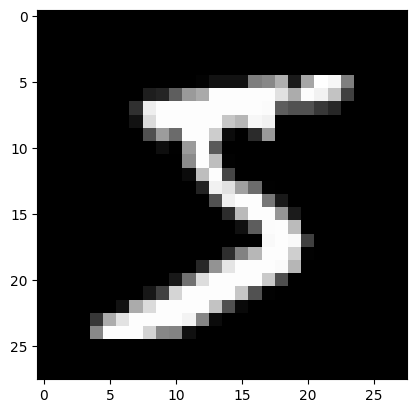

First label: tensor(5)


In [3]:
transform = transforms.ToTensor()  # 0~1 float
# Load datasets
data_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
data_valid = datasets.MNIST(root='./data', train=False, transform=transform)
# Access first image and label
first_image, first_label = data_train[0] 
# Convert dataset to full tensors if needed
train_images = torch.stack([img for img, _ in data_train]).squeeze(1)  # [60000,28,28]
train_labels = torch.tensor([label for _, label in data_train])        # [60000]
valid_images = torch.stack([img for img, _ in data_valid]).squeeze(1)  # [10000,28,28]
valid_labels = torch.tensor([label for _, label in data_valid])         # [10000]
# Print info 
print("data_train length:", len(data_train))        # 60000
print("data_valid length:", len(data_valid))        # 10000
print("train_images shape:", train_images.shape)    # torch.Size([60000,28,28])
print("train_images dtype:", train_images.dtype)    # torch.float32
print("First image tensor:\n", train_images[0,:,:])
plt.imshow(train_images[0,:,:], cmap='gray') # Guess and check it!
plt.show()
print("First label:", train_labels[0])

Define hyperparameters

In [4]:
EPOCH_MAX = 500
EPOCH_LOG = 100
OPTIMIZER_PARAM = {'lr': 0.1}
DATA_LOADER_PARAM = { 'batch_size': 64, 'shuffle': True }
SCHEDULER_PARAM = { 'step_size': 500, 'gamma': 0.1 }
USE_CUDA = torch.cuda.is_available()
print("USE_CUDA", USE_CUDA)
RANDOM_SEED = 777

USE_CUDA False


A four-layer CNN model<br>
- Try more or less layers, channels, and kernel size<br>
- Try to apply batch normalization (e.g. 'nn.BatchNorm' and 'nn.BatchNorm2d')<br>

In [5]:
class MyCNN(nn.Module):
    def __init__(self):
        super(MyCNN, self).__init__()
        # Notation: (batch_size, channel, height, width)
        # Input : (batch_size, 1, 28, 28)
        # Layer1: conv (batch_size, 32, 28, 28)
        # pool (batch_size, 32, 14, 14)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        # Layer2: conv (batch_size, 64, 14, 14)
        # pool (batch_size, 64, 7, 7)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.drop2 = nn.Dropout(0.2)
        # Input : (batch_size, 64*7*7)
        # Layer3: fc (batch_size, 512)
        self.fc3 = nn.Linear(64*7*7, 512)
        self.drop3 = nn.Dropout(0.2)
        # Layer4: fc (batch_size, 10)
        self.fc4 = nn.Linear(512, 10)
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.drop2(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc3(x))
        x = self.drop3(x)
        x = F.log_softmax(self.fc4(x), dim=1)
        return x

Train a model with the given batches

In [ ]:
def train(model, batch_data, loss_func, optimizer):
    model.train() # Notify layers (e.g. DropOut, BatchNorm) that it is now training
    train_loss, n_data = 0, 0
    dev = next(model.parameters()).device
    for batch_idx, (x, y) in enumerate(batch_data):
        x, y = x.to(dev), y.to(dev)
        optimizer.zero_grad()
        output = model(x)
        loss = loss_func(output, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        n_data += len(y)
        return train_loss / n_data

Evaluate a model with the given batches

In [ ]:
def evaluate(model, batch_data, loss_func):
    model.eval() # Notify layers (e.g. DropOut, BatchNorm) that it is now testing
    test_loss, n_correct, n_data = 0, 0, 0
    with torch.no_grad():
        dev = next(model.parameters()).device
    for x, y in batch_data:
        x, y = x.to(dev), y.to(dev)
        output = model(x)
        loss = loss_func(output, y)
        y_pred = torch.argmax(output, dim=1)
        test_loss += loss.item()
        n_correct += (y == y_pred).sum().item()
        n_data += len(y)
        return test_loss / n_data, n_correct / n_data

Predict a digit using the given model

In [8]:
def predict(image, model):
    """
    Predict a digit using a trained PyTorch model.
    Args:
        image: torch.Tensor [1,28,28] or PIL.Image
        model: trained PyTorch model
    Returns:
        int: predicted digit
    """
    model.eval()
    with torch.no_grad():
        # Convert input to tensor [1,28,28] float in [0,1]
        if isinstance(image, torch.Tensor):
            tensor = image.float()  # already 0~1 if using ToTensor
            if tensor.ndim == 2:
                tensor = tensor.unsqueeze(0)  # add channel dim
        else:
            tensor = TF.to_tensor(image)  # PIL -> [1,28,28]
        # Add batch dimension: [1,1,28,28]
        tensor = tensor.unsqueeze(0)
        # Move to model device
        device = next(model.parameters()).device
        tensor = tensor.to(device)
        # Forward pass
        output = model(tensor)
        pred = torch.argmax(output, dim=1)
        return pred.item()

In [9]:
if __name__ == '__main__':
    # 0. Preparation
    torch.manual_seed(RANDOM_SEED)
    if USE_CUDA:
        torch.cuda.manual_seed_all(RANDOM_SEED)
    dev = torch.device('cuda' if USE_CUDA else 'cpu')

    # 1. Load the MNIST dataset
    preproc = torchvision.transforms.ToTensor()
    data_train = torchvision.datasets.MNIST(DATA_PATH, train=True, download=True, transform=preproc)
    data_valid = torchvision.datasets.MNIST(DATA_PATH, train=False, transform=preproc)
    loader_train = torch.utils.data.DataLoader(data_train, **DATA_LOADER_PARAM)
    loader_valid = torch.utils.data.DataLoader(data_valid, **DATA_LOADER_PARAM)

    # 2. Instantiate a model, loss function, and optimizer
    model = MyCNN().to(dev)
    loss_func = F.cross_entropy
    optimizer = torch.optim.SGD(model.parameters(), **OPTIMIZER_PARAM)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, **SCHEDULER_PARAM)

    # 3.1. Train the model
    loss_list = []
    start = time.time()
    for epoch in range(1, EPOCH_MAX + 1):
        train_loss = train(model, loader_train, loss_func, optimizer)
        valid_loss, valid_accuracy = evaluate(model, loader_valid, loss_func)
        scheduler.step()
        loss_list.append([epoch, train_loss, valid_loss, valid_accuracy])
        if epoch % EPOCH_LOG == 0:
            elapse = (time.time() - start) / 60
            print(f'{epoch:>6} ({elapse:>6.2f} min), TrLoss={train_loss:.6f}, VaLoss={valid_loss:.6f}, VaAcc={valid_accuracy:.3f}, lr={scheduler.get_last_lr()}')
    elapse = (time.time() - start) / 60
    
    # # 3.2. Save the trained model if necessary
    # if SAVE_MODEL:
    #     torch.save(model.state_dict(), SAVE_MODEL)

   100 (  0.24 min), TrLoss=0.005305, VaLoss=0.005260, VaAcc=0.859, lr=[0.1]
   200 (  0.48 min), TrLoss=0.004646, VaLoss=0.000844, VaAcc=1.000, lr=[0.1]
   300 (  0.72 min), TrLoss=0.002027, VaLoss=0.000782, VaAcc=0.969, lr=[0.1]
   400 (  0.95 min), TrLoss=0.002691, VaLoss=0.000922, VaAcc=0.984, lr=[0.1]
   500 (  1.20 min), TrLoss=0.000954, VaLoss=0.001897, VaAcc=0.984, lr=[0.010000000000000002]


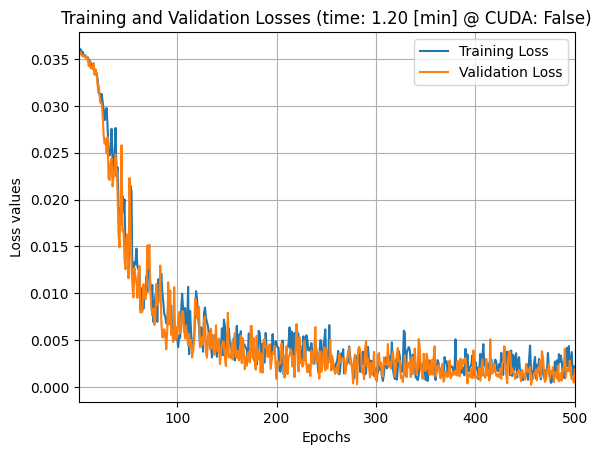

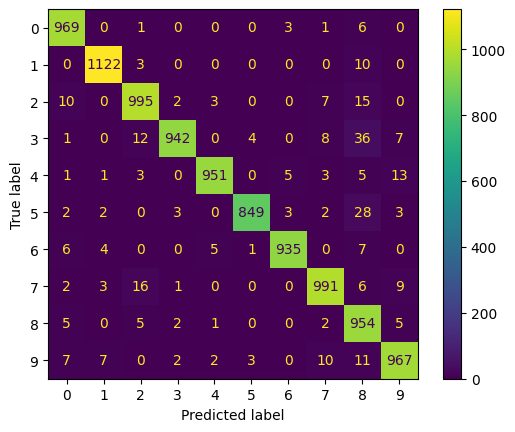

5


In [10]:
    # 4.1. Visualize the loss curves
    plt.title(f'Training and Validation Losses (time: {elapse:.2f} [min] @ CUDA: {USE_CUDA})')
    loss_array = np.array(loss_list)
    plt.plot(loss_array[:,0], loss_array[:,1], label='Training Loss')
    plt.plot(loss_array[:,0], loss_array[:,2], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss values')
    plt.xlim(loss_array[0,0], loss_array[-1,0])
    plt.grid()
    plt.legend()
    plt.show()

    # # 4.2. Visualize the confusion matrix
    valid_images = torch.stack([img for img, _ in data_valid]).squeeze(1)  # [10000,28,28]
    valid_labels = torch.tensor([label for _, label in data_valid])         # [10000]
    predicts = [predict(datum, model) for datum in valid_images]  
    conf_mat = metrics.confusion_matrix(valid_labels, predicts)
    conf_fig = metrics.ConfusionMatrixDisplay(conf_mat)
    conf_fig.plot()
    plt.show()

    # 5. Test your image
    print(predict(train_images[0], model)) # 5  

    # import torch, PIL
    # from cnn_mnist import MyCNN, predict
    
    # # Load a model
    # model = MyCNN()
    # model.load_state_dict(torch.load('cnn_mnist.pt'))
    
    # # Test the model
    # with PIL.Image.open('data/cnn_mnist_test.png').convert('L') as image:
    #     print(predict(image, model))